### imports

In [1]:
import shutil, os, subprocess
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import random
from PIL import Image
from IPython.display import display, Markdown


In [2]:
%config InlineBackend.figure_format = 'retina'

In [ ]:
def generate_matplotlib_data(limit=100):
    if os.path.exists("plot2code_exec.jsonl") and len(open("plot2code_exec.jsonl").readlines()) > 0:
        print(f"⚠️ dataset already exists, skipping data generation")
        return
      
    print("dataset not found, generating new data...")
    # download matplotlib examples
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/matplotlib/matplotlib.git
    %cd matplotlib
    !git sparse-checkout init --cone
    !git sparse-checkout set galleries/examples
    %cd ..
    
    root = Path("matplotlib/galleries/examples")
    keep = ["lines_bars_and_markers", "pie_and_polar_charts", "statistics", "mplot3d"]

    for p in root.iterdir():
        if p.is_dir() and p.name not in keep:
            shutil.rmtree(p)
            print("🗑️ deleted", p)
            
            
    
    gallery_dir = Path("plot_gallery_exec")
    gallery_dir.mkdir(exist_ok=True)

    dataset = []

    examples = list(root.rglob("*.py"))

    for f in tqdm(examples[:min(limit,len(examples))]):
        out_png = gallery_dir / (f.stem + ".png")
        try:
            code = open(f).read()
            # run safely in isolated process using non-interactive backend
            cmd = f"""import matplotlib; matplotlib.use('Agg');
import matplotlib.pyplot as plt;
exec(open(r'{f}').read());
plt.savefig(r'{out_png}');"""
            subprocess.run(["python", "-c", cmd], check=True, timeout=20)
            dataset.append({"image": str(out_png), "code": code})
        except Exception as e:
            pass

    print(f"✅ Generated {len(dataset)} plots")
    with open("plot2code_exec.jsonl", "w") as f:
        for d in dataset:
            f.write(json.dumps(d) + "\n")
            

# TODO: give function args examples categories?

In [6]:
generate_matplotlib_data()

dataset not found, generating new data...
fatal: destination path 'matplotlib' already exists and is not an empty directory.


/mnt/bdrv/slab/plt2cd/plot2code/matplotlib
/mnt/bdrv/slab/plt2cd/plot2code


  2%|▏         | 2/100 [00:03<02:35,  1.58s/it]<string>:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:96: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  4%|▍         | 4/100 [00:06<02:35,  1.62s/it]<string>:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:189: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:234: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  5%|▌         | 5/100 [00:08<02:28,  1.56s/it]<string>:152: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:185: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:216: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  6%|▌         | 6/100 [00:09<02:14,  1.43s/it]Traceback (most recent 

0.225 sec. elapsed
0.105 sec. elapsed


<string>:93: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
 23%|██▎       | 23/100 [00:37<02:16,  1.78s/it]<string>:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
 25%|██▌       | 25/100 [00:40<01:56,  1.56s/it]<string>:94: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:124: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
 26%|██▌       | 26/100 [00:41<01:51,  1.50s/it]<string>:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:118: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
 29%|██▉       | 29/100 [00:45<01:34,  1.34s/it]<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:32: UserWarni

✅ Generated 94 plots


✅ Loaded 94 samples


### 🖼️ `step_demo.png`

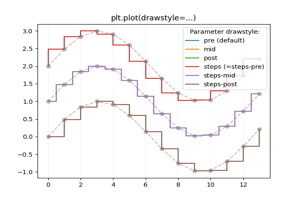

```python
"""
=========
Step Demo
=========

This example demonstrates the use of `.pyplot.step` for piece-wise constant
curves. In particular, it illustrates the effect of the parameter *where*
on the step position.

.. note::

    For the common case that you know the edge positions, use `.pyplot.stairs`
    instead.

The circular markers created with `.pyplot.plot` show the actual data
positions so that ...
```

### 🖼️ `scatter_with_legend.png`

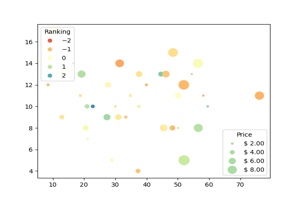

```python
"""
==========================
Scatter plot with a legend
==========================

To create a scatter plot with a legend one may use a loop and create one
`~.Axes.scatter` plot per item to appear in the legend and set the ``label``
accordingly.

The following also demonstrates how transparency of the markers
can be adjusted by giving ``alpha`` a value between 0 and 1.
"""

import matplotlib.py...
```

### 🖼️ `timeline.png`

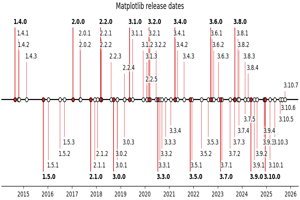

```python
"""
====================================
Timeline with lines, dates, and text
====================================

How to create a simple timeline using Matplotlib release dates.

Timelines can be created with a collection of dates and text. In this example,
we show how to create a simple timeline using the dates for recent releases
of Matplotlib. First, we'll pull the data from GitHub.
"""

from...
```

### 🖼️ `stackplot_demo.png`

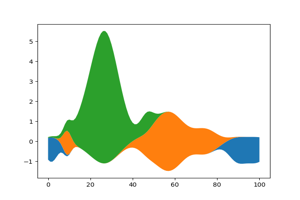

```python
"""
===========================
Stackplots and streamgraphs
===========================
"""

# %%
# Stackplots
# ----------
#
# Stackplots draw multiple datasets as vertically stacked areas. This is
# useful when the individual data values and additionally their cumulative
# value are of interest.


import matplotlib.pyplot as plt
import numpy as np

import matplotlib.ticker as mticker

# data fro...
```

### 🖼️ `boxplot_color.png`

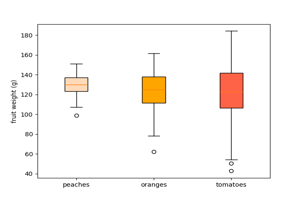

```python
"""
=================================
Box plots with custom fill colors
=================================

To color each box of a box plot individually:

1) use the keyword argument ``patch_artist=True`` to create filled boxes.
2) loop through the created boxes and adapt their color.
"""

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(19680801)
fruit_weights = [
    np.random.n...
```

In [7]:
# Load dataset
data = [json.loads(l) for l in open("plot2code_exec.jsonl")]

print(f"✅ Loaded {len(data)} samples")

# Show 5 random examples
for sample in random.sample(data, min(5, len(data))):
    display(Markdown(f"### 🖼️ `{Path(sample['image']).name}`"))
    display(Image.open(sample["image"]).resize((300, 200)))
    display(Markdown(f"```python\n{sample['code'][:400]}...\n```"))

In [21]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",   # important on CUDA 12.4
)

# 🔧 critical: set pad_token_id to eos to avoid device-side asserts
eos_id = processor.tokenizer.eos_token_id
model.generation_config.eos_token_id = eos_id
model.generation_config.pad_token_id = eos_id


Loading checkpoint shards: 100%|██████████| 5/5 [00:00<00:00, 36.69it/s]


In [22]:
from PIL import Image

def gen_code_for_image(img_path, max_new_tokens=512, temperature=0.0):
    img = Image.open(img_path).convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",
             "text": ("You are a Matplotlib expert. "
                      "Write minimal runnable Python code to recreate this plot. "
                      "Use only matplotlib.pyplot (and numpy if needed). "
                      "Return ONLY a fenced Python code block.")
            },
        ],
    }]

    # chat template → **string** with special vision tokens
    convo = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # ✅ single processor call (provides input_ids/attn + pixel_values coherently)
    inputs = processor(text=[convo], images=[img], return_tensors="pt").to(model.device, dtype)

    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=False,
            use_cache=True,
        )
    return processor.batch_decode(out, skip_special_tokens=True)[0]


In [23]:
# demo on one image
print(gen_code_for_image("plot_gallery_exec/simple_plot.png"))


system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, s)

# Add title and labels
plt.title('About as simple as it gets, folks')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')

# Display the plot
plt.show()
```


In [26]:
import io, re, json, numpy as np, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, Markdown

# --- Helper functions ---

def extract_code(text):
    """Extract fenced Python block from LLM output."""
    m = re.search(r"```(?:python)?\s*([\s\S]*?)```", text)
    if m:
        print("✅ Extracted fenced Python code block.")
        return m.group(1).strip()
    else:
        print("⚠️ No fenced code block found; using raw text.")
        return text.strip()

def render_code_to_png(py_code, out_path):
    """Safely execute matplotlib code and save to file."""
    import builtins
    safe_builtins = {
        "range": range,
        "len": len,
        "print": print,
        "__import__": builtins.__import__,
    }

    safe_globals = {
        "__builtins__": safe_builtins,
        "np": __import__("numpy"),
        "plt": plt,
    }

    plt.close("all")
    try:
        print("▶️ Executing generated code ...")
        exec(py_code, safe_globals, None)
        if not plt.get_fignums():
            print("⚠️ No figure created by code — creating empty figure.")
            plt.figure()
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.close("all")
        print(f"💾 Saved recreated plot → {out_path}")
        return True
    except Exception as e:
        print(f"❌ Execution failed: {e}")
        return False

def image_ssim(img_a, img_b):
    """Compute SSIM between two images (grayscale)."""
    print("🔍 Computing SSIM ...")
    a = np.array(Image.open(img_a).convert("L"))
    b = np.array(Image.open(img_b).convert("L"))
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    score = float(ssim(a, b))
    print(f"📈 SSIM score: {score:.4f}")
    return score

def show_side_by_side(ref_path, gen_path, score):
    """Display reference + generated + SSIM score."""
    ref = Image.open(ref_path).resize((400, 300))
    gen = Image.open(gen_path).resize((400, 300))
    combined = Image.new("RGB", (800, 300))
    combined.paste(ref, (0, 0))
    combined.paste(gen, (400, 0))
    display(Markdown(f"**SSIM:** `{score:.3f}`"))
    display(combined)

# --- Evaluation for one image ---

def evaluate_plot2code(img_path):
    print(f"\n🖼️ Evaluating {img_path} ...")

    # 1️⃣ Generate code from model
    print("💬 Querying model ...")
    result_text = gen_code_for_image(img_path)
    print("\n🧠 Model output:\n" + "-"*60)
    print(result_text[:1000] + ("\n..." if len(result_text) > 1000 else ""))
    print("-"*60)

    # 2️⃣ Extract code
    code = extract_code(result_text)
    print("\n🧾 Extracted code:\n" + "-"*60)
    print(code[:500] + ("\n..." if len(code) > 500 else ""))
    print("-"*60)

    # 3️⃣ Execute and render
    gen_path = "recreated.png"
    if render_code_to_png(code, gen_path):
        # 4️⃣ Evaluate
        score = image_ssim(img_path, gen_path)
        display(Markdown(f"### ✅ {img_path}"))
        show_side_by_side(img_path, gen_path, score)
    else:
        print("❌ Skipping SSIM — code execution failed.")



🖼️ Evaluating plot_gallery_exec/simple_plot.png ...
💬 Querying model ...

🧠 Model output:
------------------------------------------------------------
system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, s)

# Add title and labels
plt.title('About as simple as it gets, folks')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')

# Display the plot
plt.show()
```
------------------------------------------------------------
✅ Extracted fenced Python code block.

🧾 Extracted code:
------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 

### ✅ plot_gallery_exec/simple_plot.png

**SSIM:** `0.628`

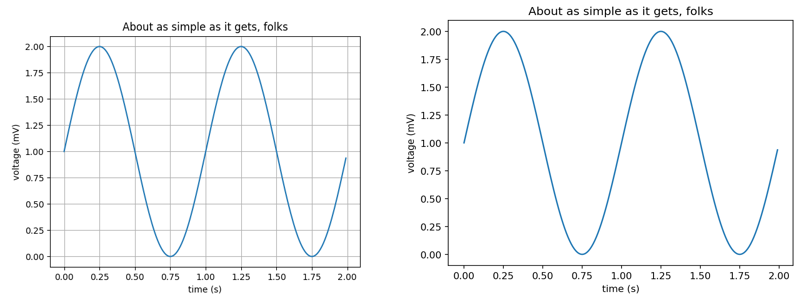

In [27]:
evaluate_plot2code("plot_gallery_exec/simple_plot.png")


TODO

1. Clean up notebook -- if dataset exists, skip generation steps
2. Remove Unicode characters 
3. Run in batch mode over all images
4. Report SSIM scores
5. Decouple data generation and model training notebooks
6. Decouple evaluation and zero-shot code gen
7. Add additional metrics -- exec@1
8. Fine-tune model on this data
9. Keep a clean test set separate from training data
10. On test set evaluate zero shot and fine-tuned model